In [2]:
import os
import math
import random
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

RESUME_TRAINING = True
VRAM_FRACTION   = 1.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.cuda.set_per_process_memory_fraction(VRAM_FRACTION, device=0)
    print(f'Using device: {device}  |  VRAM cap: {VRAM_FRACTION*100:.0f}%')
else:
    print('Using device: cpu')

DATA_ROOT  = os.path.join(os.getcwd(), 'data')
MODEL_ROOT = os.path.join(os.getcwd(), 'models')
os.makedirs(MODEL_ROOT, exist_ok=True)

Using device: cuda  |  VRAM cap: 100%


In [3]:
from helper_functions.utils import MARSDataset

MARS_ROOT = os.path.join(DATA_ROOT, 'MARS')

dataset_train = MARSDataset(os.path.join(MARS_ROOT, 'bounding_box_train'), min_seq_len=2)
dataset_test  = MARSDataset(os.path.join(MARS_ROOT, 'bounding_box_test'),  min_seq_len=1)

all_seqs_train = [s for cams in dataset_train.sequences_by_person.values()
                    for seqs in cams.values() for s in seqs]
all_seqs_test  = [s for cams in dataset_test.sequences_by_person.values()
                    for seqs in cams.values() for s in seqs]

print(f'Train identities: {len(dataset_train.sequences_by_person)}')
print(f'Train sequences:  {len(all_seqs_train)}')
print(f'Test  identities: {len(dataset_test.sequences_by_person)}')
print(f'Test  sequences:  {len(all_seqs_test)}')

Train identities: 625
Train sequences:  8298
Test  identities: 634
Test  sequences:  8062


In [4]:
import numpy as np

lens = [len(s) for s in all_seqs_train]
print(f'Train seq lengths -- mean: {np.mean(lens):.1f}  median: {np.median(lens):.0f}  '
      f'p95: {np.percentile(lens,95):.0f}  p99: {np.percentile(lens,99):.0f}  max: {max(lens)}')

Train seq lengths -- mean: 61.5  median: 36  p95: 186  p99: 277  max: 900


In [5]:
import torchvision.transforms as T
from torch.utils.data import Sampler

MAX_SEQ_LEN = 64
P, K = 12, 4

train_transform = T.Compose([
    T.Resize((256, 128)),
    T.RandomHorizontalFlip(),
    T.Pad(10),
    T.RandomCrop((256, 128)),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3)),
])

test_transform = T.Compose([
    T.Resize((256, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class SequenceLabelDataset(Dataset):
    def __init__(self, sequences_by_person, transform, max_seq_len):
        self.transform          = transform
        self.max_seq_len        = max_seq_len
        self.samples            = []
        self.pid_to_indices     = {}
        self.pid_cam_to_indices = {}

        for pid, cam_data in sequences_by_person.items():
            for cam, seqs in cam_data.items():
                for seq in seqs:
                    i = len(self.samples)
                    self.samples.append((seq, pid))
                    self.pid_to_indices.setdefault(pid, []).append(i)
                    self.pid_cam_to_indices.setdefault(pid, {}).setdefault(cam, []).append(i)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, pid = self.samples[idx]
        paths  = [p.image_path for p in seq[:self.max_seq_len]]
        frames = [self._load(p) for p in paths]
        return torch.stack(frames), len(frames), pid

    def _load(self, path):
        return self.transform(Image.open(path).convert('RGB'))


class PKSampler(Sampler):
    def __init__(self, pid_to_indices, pid_cam_to_indices, P=12, K=4):
        self.pid_to_indices     = pid_to_indices
        self.pid_cam_to_indices = pid_cam_to_indices
        self.P = P
        self.K = K
        self.pids = [pid for pid, idxs in pid_to_indices.items() if len(idxs) >= 2]

    def _sample_cross_camera(self, pid):
        cam_data = self.pid_cam_to_indices[pid]
        cameras  = list(cam_data.keys())
        if len(cameras) == 1:
            return random.choices(self.pid_to_indices[pid], k=self.K)
        random.shuffle(cameras)
        cam_cycle = cameras * (self.K // len(cameras) + 1)
        return [random.choice(cam_data[cam]) for cam in cam_cycle[:self.K]]

    def __iter__(self):
        pids = self.pids.copy()
        random.shuffle(pids)
        for i in range(0, len(pids) - self.P + 1, self.P):
            batch = []
            for pid in pids[i : i + self.P]:
                batch.extend(self._sample_cross_camera(pid))
            yield batch

    def __len__(self):
        return len(self.pids) // self.P


def sequence_label_collate(batch):
    imgs_list, lengths, pids = zip(*batch)
    max_t = max(lengths)
    C, H, W = imgs_list[0].shape[1:]
    padded = torch.zeros(len(imgs_list), max_t, C, H, W)
    for i, (imgs, t) in enumerate(zip(imgs_list, lengths)):
        padded[i, :t] = imgs
    return padded, torch.tensor(lengths, dtype=torch.long), torch.tensor(pids, dtype=torch.long)

In [6]:
train_dataset = SequenceLabelDataset(
    dataset_train.sequences_by_person,
    transform=train_transform,
    max_seq_len=MAX_SEQ_LEN
)

sampler = PKSampler(train_dataset.pid_to_indices,
                    train_dataset.pid_cam_to_indices, P=P, K=K)

print(f'Train sequences:       {len(train_dataset)}')
print(f'Persons with >=2 seqs: {len(sampler.pids)}')
print(f'Steps per epoch:       {len(sampler)}')

train_loader = DataLoader(
    train_dataset,
    batch_sampler=sampler,
    collate_fn=sequence_label_collate,
    pin_memory=True,
    num_workers=0
)

Train sequences:       8298
Persons with >=2 seqs: 624
Steps per epoch:       52


In [7]:
from helper_functions.model import ImprovedSeqToSeqReIDModel, CombinedReIDLoss

all_train_pids = sorted(dataset_train.sequences_by_person.keys())
pid_to_cls     = {pid: i for i, pid in enumerate(all_train_pids)}
NUM_CLASSES    = len(all_train_pids)
print(f'Training identities: {NUM_CLASSES}')

model = ImprovedSeqToSeqReIDModel(
    embedding_dim=512,
    rnn_hidden=512,
    num_classes=NUM_CLASSES
).to(device)

vit_base_lr = 5e-6
decay       = 0.75

param_groups = []
param_groups.append({
    'params': list(model.encoder.vit.patch_embed.parameters()) +
              [model.encoder.vit.pos_embed, model.encoder.vit.cls_token],
    'lr': vit_base_lr * (decay ** 12)
})
for i, block in enumerate(model.encoder.vit.blocks):
    param_groups.append({'params': list(block.parameters()), 'lr': vit_base_lr * (decay ** (11 - i))})
param_groups.append({'params': list(model.encoder.vit.norm.parameters()), 'lr': vit_base_lr})

head_params = (
    list(model.encoder.global_proj.parameters()) +
    list(model.encoder.local_proj_2.parameters()) +
    list(model.encoder.local_proj_4.parameters()) +
    list(model.encoder.local_proj_8.parameters()) +
    list(model.encoder.temporal_tf.parameters()) +
    list(model.encoder.rnn.parameters()) +
    list(model.encoder.attention.parameters()) +
    list(model.encoder.embed_head.parameters()) +
    (list(model.classifier.parameters()) if model.classifier is not None else [])
)
param_groups.append({'params': head_params, 'lr': 5e-5})

WARMUP_EPOCHS = 5
optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=1e-3, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-8, verbose=True
)
scaler    = torch.amp.GradScaler('cuda')
criterion = CombinedReIDLoss(margin=0.3, circle_m=0.25, circle_gamma=80,
                              lambda_circle=0.3, lambda_stripe=0.3,
                              am_scale=30.0, am_margin=0.35).to(device)

BEST_CKPT   = os.path.join(MODEL_ROOT, 'best_model_mars.pth')
LATEST_CKPT = os.path.join(MODEL_ROOT, 'latest_model_mars.pth')

if RESUME_TRAINING:
    for ckpt in [LATEST_CKPT, BEST_CKPT]:
        if os.path.exists(ckpt):
            model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
            print(f'Resumed from {os.path.basename(ckpt)}')
            break
    else:
        print('WARNING: RESUME_TRAINING=True but no checkpoint found. Starting fresh.')
else:
    print('Starting from scratch.')


c:\Users\jokub\miniforge3\envs\tiriamasis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training identities: 625


c:\Users\jokub\miniforge3\envs\tiriamasis\lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\cb\pytorch_1000000000000\work\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(
c:\Users\jokub\miniforge3\envs\tiriamasis\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Resumed from best_model_mars.pth


In [8]:
def train_epoch(model, loader, optimizer, scaler, device, pid_to_cls, criterion):
    model.train()
    total_loss = 0.0
    comp_sums  = {"id_loss": 0.0, "triplet_loss": 0.0,
                  "circle_loss": 0.0, "stripe_loss": 0.0}
    n = 0

    for imgs, lengths, pids in tqdm(loader, desc="Train"):
        imgs = imgs.to(device)
        pids = pids.to(device)
        cls_labels = torch.tensor([pid_to_cls[p.item()] for p in pids],
                                   dtype=torch.long, device=device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            embeddings, logits, stripe_feats = model(imgs, lengths)
            loss, loss_dict = criterion(embeddings, cls_labels, logits,
                                        stripe_feats=stripe_feats, lengths=lengths)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        for k in comp_sums:
            v = loss_dict[k]
            comp_sums[k] += v.item() if hasattr(v, "item") else float(v)
        n += 1

    avg_total = total_loss / n if n > 0 else 0.0
    avg_comps = {k: v / n for k, v in comp_sums.items()} if n > 0 else comp_sums
    return avg_total, avg_comps

In [9]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import gc

def encode_sequences(sequences, model, transform, device,
                      max_seq_len=None, batch_size=32, flip_tta=False):
    model.eval()

    def seq_len(seq):
        s = seq if max_seq_len is None else seq[:max_seq_len]
        return len(s)

    sequences = sorted(sequences, key=seq_len)
    all_embs, all_pids = [], []

    def load_seq(seq, flipped=False):
        frames_to_use = seq if max_seq_len is None else seq[:max_seq_len]
        frames = []
        for p in frames_to_use:
            img = Image.open(p.image_path).convert('RGB')
            if flipped:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            frames.append(transform(img))
        return torch.stack(frames), len(frames), seq[0].person_id

    def run_batch(batch_seqs, flipped=False):
        results = [load_seq(s, flipped) for s in batch_seqs]
        imgs_list, lengths, pids = zip(*results)
        max_t = max(lengths)
        C, H, W = imgs_list[0].shape[1:]
        padded = torch.zeros(len(imgs_list), max_t, C, H, W)
        for i, (imgs, t) in enumerate(zip(imgs_list, lengths)):
            padded[i, :t] = imgs
        lengths_t = torch.tensor(lengths, dtype=torch.long)
        with torch.amp.autocast('cuda'):
            embs = model(padded.to(device), lengths_t)
        return embs.cpu().float(), pids

    with torch.no_grad():
        for start in tqdm(range(0, len(sequences), batch_size), desc='Encoding'):
            batch_seqs = sequences[start : start + batch_size]
            embs, pids = run_batch(batch_seqs)
            if flip_tta:
                embs_flip, _ = run_batch(batch_seqs, flipped=True)
                import torch.nn.functional as F
                embs = F.normalize((embs + embs_flip) / 2, dim=1)
            all_embs.append(embs.numpy())
            all_pids.extend(pids)

    return np.concatenate(all_embs, axis=0), np.array(all_pids)


def evaluate(query_embs, query_pids, gallery_embs, gallery_pids):
    sim        = cos_sim(query_embs, gallery_embs)
    sorted_idx = np.argsort(-sim, axis=1)
    rank1 = np.mean(gallery_pids[sorted_idx[:, 0]] == query_pids)
    aps = []
    for i in range(len(query_pids)):
        relevant = gallery_pids[sorted_idx[i]] == query_pids[i]
        if relevant.sum() == 0:
            continue
        cum  = np.cumsum(relevant)
        prec = cum / (np.arange(1, len(relevant) + 1))
        aps.append(prec[relevant].mean())
    return rank1, float(np.mean(aps)) if aps else 0.0

In [10]:

query_seqs, gallery_seqs = [], []

for pid, cam_data in dataset_test.sequences_by_person.items():
    cameras = list(cam_data.keys())
    if len(cameras) < 2:
        for seqs in cam_data.values():
            gallery_seqs.extend(seqs)
        continue
    query_cam = cameras[0]
    for cam, seqs in cam_data.items():
        if cam == query_cam:
            query_seqs.append(seqs[0])
        else:
            gallery_seqs.extend(seqs)

print(f'Query sequences:   {len(query_seqs)}')
print(f'Gallery sequences: {len(gallery_seqs)}')

Query sequences:   626
Gallery sequences: 5853


In [10]:
NUM_EPOCHS = 100
PATIENCE   = 15

best_score       = 0.0
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    train_loss, loss_comps = train_epoch(model, train_loader, optimizer, scaler,
                                         device, pid_to_cls, criterion)

    torch.save(model.state_dict(), LATEST_CKPT)

    gc.collect()
    torch.cuda.empty_cache()
    q_embs, q_pids = encode_sequences(query_seqs,   model, test_transform, device,
                                       max_seq_len=16, flip_tta=False)
    g_embs, g_pids = encode_sequences(gallery_seqs, model, test_transform, device,
                                       max_seq_len=16, flip_tta=False)
    model.train()
    gc.collect()
    torch.cuda.empty_cache()
    rank1, mAP = evaluate(q_embs, q_pids, g_embs, g_pids)
    score = rank1 + mAP

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}]  '
          f'loss={train_loss:.4f}  '
          f'id={loss_comps["id_loss"]:.4f}  '
          f'tri={loss_comps["triplet_loss"]:.4f}  '
          f'cir={loss_comps["circle_loss"] * criterion.lambda_circle:.4f}  '
          f'stripe={loss_comps["stripe_loss"] * criterion.lambda_stripe:.4f}  '
          f'Rank-1={rank1:.4f}  mAP={mAP:.4f}  score={score:.4f}')

    if epoch < WARMUP_EPOCHS:
        warmup_scheduler.step()
    else:
        scheduler.step(score)

    if score > best_score:
        best_score       = score
        patience_counter = 0
        torch.save(model.state_dict(), BEST_CKPT)
        print(f'  --> Saved best model  (score={best_score:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print('Early stopping.')
            break

print(f'Best score: {best_score:.4f}')

print('\n=== Stripe similarity diagnostics ===')
model.eval()
with torch.no_grad():
    sample_imgs, sample_lengths, _ = next(iter(train_loader))
    sample_imgs = sample_imgs.to(device)
    import torch.nn.functional as F
    _, stripe_feats = model.encoder(sample_imgs, sample_lengths)
    sf = F.normalize(stripe_feats, dim=-1)

    for s in range(sf.shape[2]):
        sims = []
        for b in range(sf.shape[0]):
            L = sample_lengths[b].item()
            if L < 2:
                continue
            feat = sf[b, :L, s, :]
            sim  = feat @ feat.T
            off  = ~torch.eye(L, dtype=torch.bool, device=feat.device)
            sims.append(sim[off].mean().item())
        print(f'  Stripe {s} intra-sim (want > {criterion.stripe_loss.margin_intra}): {np.mean(sims):.3f}')

    B, T = sf.shape[0], sf.shape[1]
    sf_flat = sf.view(B * T, sf.shape[2], sf.shape[3])
    inter = torch.bmm(sf_flat, sf_flat.transpose(1, 2))
    off_s = ~torch.eye(sf.shape[2], dtype=torch.bool, device=sf.device)
    print(f'  Inter-stripe sim  (want < {criterion.stripe_loss.margin:.1f}):  {inter[:, off_s].mean().item():.3f}')
model.train()


Encoding: 100%|██████████| 183/183 [01:50<00:00,  1.65it/s]


Epoch [1/100]  loss=14.7012  id=11.5543  tri=0.9251  cir=2.2064  stripe=0.0154  Rank-1=0.8498  mAP=0.7543  score=1.6041
  --> Saved best model  (score=1.6041)


Encoding: 100%|██████████| 183/183 [01:49<00:00,  1.67it/s]


Epoch [2/100]  loss=14.3493  id=11.4653  tri=0.9352  cir=1.9342  stripe=0.0145  Rank-1=0.8706  mAP=0.7753  score=1.6459
  --> Saved best model  (score=1.6459)


Encoding: 100%|██████████| 183/183 [01:49<00:00,  1.67it/s]


...

Epoch [56/100]  loss=1.8139  id=1.1460  tri=0.6433  cir=0.0235  stripe=0.0011  Rank-1=0.9281  mAP=0.8636  score=1.7917


Encoding: 100%|██████████| 183/183 [01:42<00:00,  1.78it/s]


Epoch [57/100]  loss=1.7876  id=1.1314  tri=0.6384  cir=0.0168  stripe=0.0010  Rank-1=0.9249  mAP=0.8635  score=1.7885
Early stopping.
Best score: 1.7995

=== Stripe similarity diagnostics ===
  Stripe 0 intra-sim (want > 0.5): 0.819
  Stripe 1 intra-sim (want > 0.5): 0.783
  Stripe 2 intra-sim (want > 0.5): 0.766
  Stripe 3 intra-sim (want > 0.5): 0.792
  Inter-stripe sim  (want < 0.3):  0.405


/opt/conda/lib/python3.12/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


ImprovedSeqToSeqReIDModel(
  (encoder): ImprovedSequenceEncoder(
    (vit): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc

Encoding: 100%|██████████| 183/183 [09:52<00:00,  3.24s/it]


Without re-ranking: Rank-1=0.9441  mAP=0.8914
With    re-ranking: Rank-1=0.9265  mAP=0.8974


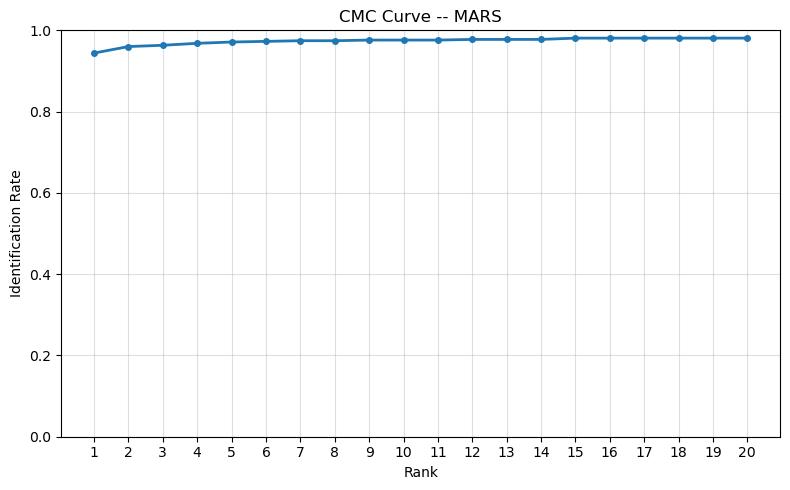

Rank-1=0.9441  Rank-5=0.9712  Rank-10=0.9760  Rank-20=0.9808  mAP=0.8914


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

model.load_state_dict(torch.load(BEST_CKPT, map_location=device, weights_only=True))

q_embs, q_pids = encode_sequences(query_seqs,   model, test_transform, device, flip_tta=True)
g_embs, g_pids = encode_sequences(gallery_seqs, model, test_transform, device,
                                   max_seq_len=MAX_SEQ_LEN, flip_tta=True)
rank1, mAP = evaluate(q_embs, q_pids, g_embs, g_pids)


def re_ranking(q_embs, g_embs, k1=20, k2=6, lambda_value=0.3):
    feat = np.concatenate([q_embs, g_embs], axis=0)
    n_q, n = len(q_embs), len(q_embs) + len(g_embs)
    dist = 2 - 2 * (feat @ feat.T).clip(-1, 1)
    initial_rank = np.argsort(dist, axis=1)
    V = np.zeros_like(dist)
    for i in range(n):
        forward = set(initial_rank[i, 1:k1+1])
        R_i = [j for j in forward if i in set(initial_rank[j, 1:k1+1])]
        R_i_exp = list(R_i)
        for q in R_i:
            R_q = set(initial_rank[q, 1:int(k1/2)+1])
            if len(R_q) and len(R_q & set(R_i)) / len(R_q) >= 2/3:
                R_i_exp += list(R_q)
        R_i_exp = list(set(R_i_exp))
        w = np.exp(-dist[i, R_i_exp])
        w /= w.sum() + 1e-12
        V[i, R_i_exp] = w
    if k2 != 1:
        V_qe = np.zeros_like(V)
        for i in range(n):
            V_qe[i] = V[initial_rank[i, :k2]].mean(axis=0)
        V = V_qe
    jaccard = np.zeros((n_q, n - n_q))
    for i in range(n_q):
        for j in range(n_q, n):
            inter = np.minimum(V[i], V[j]).sum()
            union = np.maximum(V[i], V[j]).sum()
            jaccard[i, j - n_q] = 1 - inter / (union + 1e-12)
    return jaccard * (1 - lambda_value) + dist[:n_q, n_q:] * lambda_value


def evaluate_rerank(q_embs, q_pids, g_embs, g_pids, k1=20, k2=6, lambda_value=0.3):
    dist = re_ranking(q_embs, g_embs, k1=k1, k2=k2, lambda_value=lambda_value)
    sorted_idx = np.argsort(dist, axis=1)
    rank1_rr = np.mean(g_pids[sorted_idx[:, 0]] == q_pids)
    aps = []
    for i in range(len(q_pids)):
        relevant = g_pids[sorted_idx[i]] == q_pids[i]
        if relevant.sum() == 0:
            continue
        cum  = np.cumsum(relevant)
        prec = cum / (np.arange(1, len(relevant) + 1))
        aps.append(prec[relevant].mean())
    return rank1_rr, float(np.mean(aps)) if aps else 0.0


rank1_rr, mAP_rr = evaluate_rerank(q_embs, q_pids, g_embs, g_pids)
print(f'Without re-ranking: Rank-1={rank1:.4f}  mAP={mAP:.4f}')
print(f'With    re-ranking: Rank-1={rank1_rr:.4f}  mAP={mAP_rr:.4f}')

sim        = cos_sim(q_embs, g_embs)
sorted_idx = np.argsort(-sim, axis=1)
MAX_RANK   = 20
cmc = np.zeros(MAX_RANK)
for i in range(len(q_pids)):
    matches = g_pids[sorted_idx[i]] == q_pids[i]
    for r in range(MAX_RANK):
        if matches[:r + 1].any():
            cmc[r:] += 1
            break
cmc /= len(q_pids)

plt.figure(figsize=(8, 5))
plt.plot(range(1, MAX_RANK + 1), cmc, marker='o', linewidth=2, markersize=4)
plt.xlabel('Rank')
plt.ylabel('Accuracy')
plt.title('CMC Curve MARS')
plt.xticks(range(1, MAX_RANK + 1))
plt.ylim(cmc[0] * 0.99, 1)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('mars_cmc.png', dpi=150)
plt.show()

print(f'Rank-1={cmc[0]:.4f}  Rank-5={cmc[4]:.4f}  Rank-10={cmc[9]:.4f}  Rank-20={cmc[19]:.4f}  mAP={mAP:.4f}')

In [ ]:
def aqe(q_embs, g_embs, k=7, alpha=3.0):
    sim = q_embs @ g_embs.T
    weights = np.clip(sim, 0, None) ** alpha
    top_k = np.argsort(-sim, axis=1)[:, :k]
    q_exp = q_embs.copy()
    for i in range(len(q_embs)):
        w = weights[i, top_k[i], np.newaxis]
        q_exp[i] = q_embs[i] + (w * g_embs[top_k[i]]).sum(0)
    norms = np.linalg.norm(q_exp, axis=1, keepdims=True)
    return q_exp / (norms + 1e-12)

q_exp = aqe(q_embs, g_embs, k=7, alpha=3.0)
r1_aqe, m_aqe = evaluate(q_exp, q_pids, g_embs, g_pids)
print(f'AQE only:         Rank-1={r1_aqe:.4f}  mAP={m_aqe:.4f}')

for k1 in [10, 12, 14, 16]:
    for lam in [0.2, 0.25, 0.3, 0.35]:
        r1, m = evaluate_rerank(q_embs, q_pids, g_embs, g_pids,
                                k1=k1, k2=2, lambda_value=lam)
        print(f'k1={k1:2d} λ={lam:.2f}  Rank-1={r1:.4f}  mAP={m:.4f}')

AQE only:         Rank-1=0.9233  mAP=0.8855
k1=10 λ=0.20  Rank-1=0.9393  mAP=0.9133
k1=10 λ=0.25  Rank-1=0.9409  mAP=0.9134
k1=10 λ=0.30  Rank-1=0.9409  mAP=0.9127
k1=10 λ=0.35  Rank-1=0.9409  mAP=0.9117
k1=12 λ=0.20  Rank-1=0.9377  mAP=0.9126
k1=12 λ=0.25  Rank-1=0.9393  mAP=0.9121
k1=12 λ=0.30  Rank-1=0.9393  mAP=0.9116
k1=12 λ=0.35  Rank-1=0.9409  mAP=0.9109
k1=14 λ=0.20  Rank-1=0.9329  mAP=0.9095
k1=14 λ=0.25  Rank-1=0.9329  mAP=0.9091
k1=14 λ=0.30  Rank-1=0.9345  mAP=0.9090
k1=14 λ=0.35  Rank-1=0.9345  mAP=0.9088
k1=16 λ=0.20  Rank-1=0.9393  mAP=0.9078
k1=16 λ=0.25  Rank-1=0.9425  mAP=0.9079
k1=16 λ=0.30  Rank-1=0.9425  mAP=0.9081
k1=16 λ=0.35  Rank-1=0.9425  mAP=0.9076


In [ ]:
import gc
import matplotlib.pyplot as plt
import numpy as np

model.load_state_dict(torch.load(BEST_CKPT, map_location=device, weights_only=True))

SEQ_LENS = [1] + list(range(4, 65, 4))
rank1_by_len, mAP_by_len = [], []

for L in SEQ_LENS:
    gc.collect()
    torch.cuda.empty_cache()

    q_embs_L, q_pids_L = encode_sequences(query_seqs,   model, test_transform, device,
                                           max_seq_len=L, flip_tta=False)
    g_embs_L, g_pids_L = encode_sequences(gallery_seqs, model, test_transform, device,
                                           max_seq_len=L, flip_tta=False)
    r1_L, mAP_L = evaluate(q_embs_L, q_pids_L, g_embs_L, g_pids_L)
    rank1_by_len.append(r1_L)
    mAP_by_len.append(mAP_L)
    print(f'max_seq_len={L:2d}  Rank-1={r1_L:.4f}  mAP={mAP_L:.4f}')

best_L  = SEQ_LENS[int(np.argmax(rank1_by_len))]
best_L_mAP = SEQ_LENS[int(np.argmax(mAP_by_len))]
best_r1 = max(rank1_by_len)
best_mAP = max(mAP_by_len)

Encoding: 100%|██████████| 183/183 [00:13<00:00, 13.58it/s]


max_seq_len= 1  Rank-1=0.8243  mAP=0.7188


Encoding: 100%|██████████| 183/183 [00:46<00:00,  3.95it/s]


max_seq_len= 4  Rank-1=0.8738  mAP=0.7928


Encoding: 100%|██████████| 183/183 [01:31<00:00,  2.00it/s]


...

max_seq_len=24  Rank-1=0.9393  mAP=0.8768


Encoding: 100%|██████████| 183/183 [04:38<00:00,  1.52s/it]


max_seq_len=28  Rank-1=0.9409  mAP=0.8798


Encoding:  40%|████      | 8/20 [06:47<10:11, 50.97s/it] 


KeyboardInterrupt: 

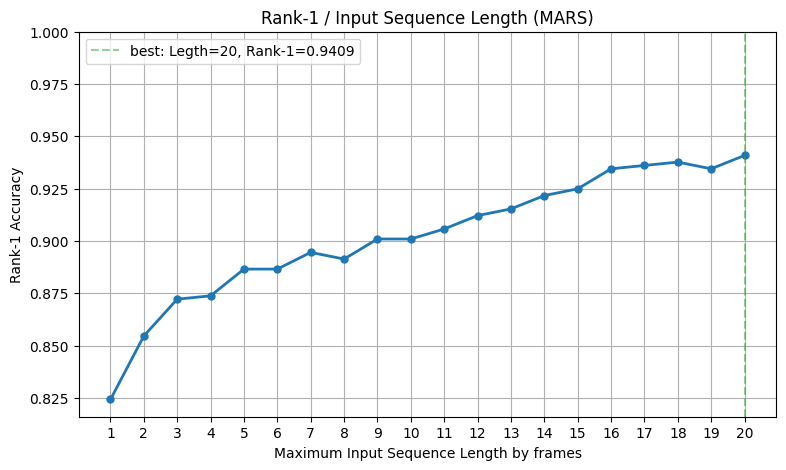

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(SEQ_LENS, rank1_by_len, marker='o', linewidth=2, markersize=5, color='tab:green', label='Rank-1')
plt.plot(SEQ_LENS, mAP_by_len, marker='s', linewidth=2, markersize=5, color='tab:orange', label='mAP')
plt.axvline( best_L, color='tab:red', linestyle='--', alpha=0.5, label=f'Best Rank-1: L={best_L}, R1={best_r1:.4f}')
plt.axvline(SEQ_LENS[int(np.argmax(mAP_by_len))], color='tab:blue', linestyle='--', alpha=0.5, label=f'Best query L={SEQ_LENS[int(np.argmax(mAP_by_len))]}, Best mAP={best_mAP:.4f}')

plt.xlabel('Maximum Input Sequence Length by frames')
plt.ylabel('Score')
plt.title('Rank-1 and mAP / Input Sequence Length on MARS')

plt.xticks(SEQ_LENS)
plt.ylim(min(min(rank1_by_len), min(mAP_by_len)) * 0.99, 1)

plt.grid(True)
plt.legend(loc='lower right')

plt.savefig('mars_rank1_map_vs_seqlen.png', dpi=150)
plt.show()

In [ ]:
import gc
import matplotlib.pyplot as plt
import numpy as np


model.load_state_dict(torch.load(BEST_CKPT, map_location=device, weights_only=True))

gc.collect()
torch.cuda.empty_cache()
g_embs_full, g_pids_full = encode_sequences(gallery_seqs, model, test_transform, device,
                                             max_seq_len=MAX_SEQ_LEN, flip_tta=False)

QUERY_SEQ_LENS = [1] + list(range(4, 65, 4))
rank1_qonly, mAP_qonly = [], []

for L in QUERY_SEQ_LENS:
    gc.collect()
    torch.cuda.empty_cache()
    q_embs_L, q_pids_L = encode_sequences(query_seqs, model, test_transform, device,
                                           max_seq_len=L, flip_tta=False)
    r1_L, mAP_L = evaluate(q_embs_L, q_pids_L, g_embs_full, g_pids_full)
    rank1_qonly.append(r1_L)
    mAP_qonly.append(mAP_L)
    print(f'query max_seq_len={L:2d}  Rank-1={r1_L:.4f}  mAP={mAP_L:.4f}')

best_L  = QUERY_SEQ_LENS[int(np.argmax(rank1_qonly))]
best_L_mAP = QUERY_SEQ_LENS[int(np.argmax(mAP_by_len))]
best_r1 = max(rank1_qonly)
best_mAP = max(mAP_qonly)

Encoding:  74%|███████▍  | 136/183 [55:09<19:03, 24.34s/it]  


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(QUERY_SEQ_LENS, rank1_qonly, marker='o', linewidth=2, markersize=5, color='tab:green', label='Rank-1')
plt.plot(QUERY_SEQ_LENS, mAP_qonly, marker='s', linewidth=2, markersize=5, color='tab:orange', label='mAP')
plt.axvline(best_L, color='tab:red', linestyle='--', alpha=0.5, label=f'Best query L={best_L}, Rank-1={best_r1:.4f}')
plt.axvline(QUERY_SEQ_LENS[int(np.argmax(mAP_qonly))], color='tab:blue', linestyle='--', alpha=0.5, label=f'Best query L={QUERY_SEQ_LENS[int(np.argmax(mAP_qonly))]}, Best mAP={best_mAP:.4f}')

plt.xlabel('Query Maximum Input Sequence Length by frames')
plt.ylabel('Score')
plt.title(f'Rank-1 and mAP / Query Length on MARS')

plt.xticks(QUERY_SEQ_LENS)
plt.ylim(min(min(rank1_qonly), min(mAP_qonly)) * 0.99, 1)

plt.grid(True)
plt.legend(loc='lower right')

plt.savefig('mars_rank1_map_vs_query_seqlen.png', dpi=150)
plt.show()

Total test frames : 681089
Total tracklets   : 12180
Query tracklets   : 1980


Scoring (official): 100%|██████████| 1980/1980 [00:02<00:00, 741.03it/s]



=== Official MARS protocol (with flip TTA) ===
  queries scored : 1980/1980
  Rank-1   : 0.8960
  Rank-5   : 0.9626
  Rank-10  : 0.9742
  Rank-20  : 0.9808
  mAP      : 0.8390


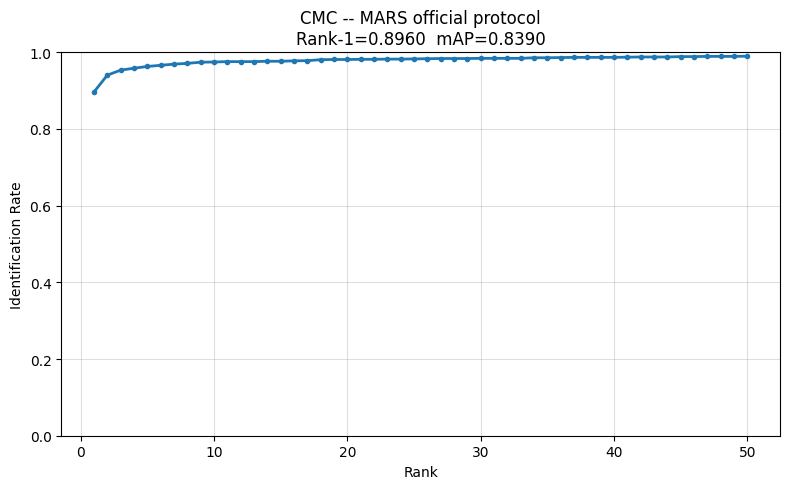

In [ ]:

import os
import gc
import scipy.io as sio
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from helper_functions.object_models import ParsedImage

INFO_DIR     = os.path.join(os.getcwd(), 'MARS-evaluation', 'info')
TEST_IMG_DIR = os.path.join(MARS_ROOT, 'bounding_box_test')

MAX_SEQ_LEN_EVAL = 64
BATCH_SIZE_EVAL  = 16
FLIP_TTA         = True

test_names = open(os.path.join(INFO_DIR, 'test_name.txt')).read().splitlines()
tracks     = sio.loadmat(os.path.join(INFO_DIR, 'tracks_test_info.mat'))['track_test_info']
query_idx  = sio.loadmat(os.path.join(INFO_DIR, 'query_IDX.mat'))['query_IDX'].flatten() - 1

print(f'Total test frames : {len(test_names)}')
print(f'Total tracklets   : {tracks.shape[0]}')
print(f'Query tracklets   : {len(query_idx)}')

def fname_to_pid_str(fname):
    return fname[:fname.index('C')]

gallery_tracklets = []
for s, e, pid, cam in tracks:
    frame_names = test_names[s - 1 : e]
    frames = []
    for fn in frame_names:
        pid_str = fname_to_pid_str(fn)
        f_idx   = int(fn[fn.index('F') + 1 : fn.index('.')])
        frames.append(ParsedImage(
            image_path = os.path.join(TEST_IMG_DIR, pid_str, fn),
            person_id  = int(pid),
            camera_id  = str(int(cam)),
            frame_id   = f_idx,
        ))
    gallery_tracklets.append(frames)

model.load_state_dict(torch.load(BEST_CKPT, map_location=device, weights_only=True))
model.eval()
gc.collect()
torch.cuda.empty_cache()

def encode_batch_in_order(batch_seqs, flipped=False):
    imgs_list, lengths = [], []
    for seq in batch_seqs:
        seq = seq[:MAX_SEQ_LEN_EVAL]
        frames = []
        for p in seq:
            img = Image.open(p.image_path).convert('RGB')
            if flipped:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            frames.append(test_transform(img))
        imgs_list.append(torch.stack(frames))
        lengths.append(len(frames))
    max_t = max(lengths)
    C, H, W = imgs_list[0].shape[1:]
    padded = torch.zeros(len(imgs_list), max_t, C, H, W)
    for i, (imgs, t) in enumerate(zip(imgs_list, lengths)):
        padded[i, :t] = imgs
    lengths_t = torch.tensor(lengths, dtype=torch.long)
    with torch.amp.autocast('cuda'):
        embs = model(padded.to(device), lengths_t)
    return embs.cpu().float()

EMB_DIM = 512
all_embs = np.zeros((len(gallery_tracklets), EMB_DIM), dtype=np.float32)
with torch.no_grad():
    for start in tqdm(range(0, len(gallery_tracklets), BATCH_SIZE_EVAL),
                      desc='Encoding (official)'):
        end   = min(start + BATCH_SIZE_EVAL, len(gallery_tracklets))
        batch = gallery_tracklets[start:end]
        embs  = encode_batch_in_order(batch, flipped=False)
        if FLIP_TTA:
            embs_flip = encode_batch_in_order(batch, flipped=True)
            embs = F.normalize((embs + embs_flip) / 2, dim=1)
        all_embs[start:end] = embs.numpy()

gallery_pids = tracks[:, 2].astype(np.int64)
gallery_cams = tracks[:, 3].astype(np.int64)

query_embs = all_embs[query_idx]
query_pids = gallery_pids[query_idx]
query_cams = gallery_cams[query_idx]

sim  = query_embs @ all_embs.T
dist = 1.0 - sim

def compute_ap_cmc_mars(score, q_pid, q_cam, g_pids, g_cams, max_rank=50):
    good = np.where((g_pids == q_pid) & (g_cams != q_cam))[0]
    same_cam = np.where((g_pids == q_pid) & (g_cams == q_cam))[0]
    distract = np.where(g_pids == -1)[0]
    junk = np.concatenate([same_cam, distract])

    order = np.argsort(score, kind='stable')
    is_good = np.isin(order, good)
    is_junk = np.isin(order, junk)
    order_clean = order[~is_junk]
    hits = np.isin(order_clean, good).astype(np.int32)

    ngood = len(good)
    if ngood == 0:
        return None, None

    cmc = np.zeros(max_rank, dtype=np.float32)
    first_hit = np.argmax(hits)
    if hits.any() and first_hit < max_rank:
        cmc[first_hit:] = 1.0

    old_recall, old_precision = 0.0, 1.0
    ap = 0.0
    intersect_size = 0
    for j, h in enumerate(hits):
        if h:
            intersect_size += 1
        recall    = intersect_size / ngood
        precision = intersect_size / (j + 1)
        ap += (recall - old_recall) * (old_precision + precision) / 2.0
        old_recall, old_precision = recall, precision
        if intersect_size == ngood:
            break
    return ap, cmc

MAX_RANK = 50
aps, cmcs = [], []
for i in tqdm(range(len(query_idx)), desc='Scoring (official)'):
    ap, cmc = compute_ap_cmc_mars(dist[i], query_pids[i], query_cams[i],
                                   gallery_pids, gallery_cams, max_rank=MAX_RANK)
    if ap is not None:
        aps.append(ap)
        cmcs.append(cmc)

cmc_official = np.stack(cmcs).mean(axis=0)
mAP_official = float(np.mean(aps))


=== Official MARS protocol (with flip TTA) ===
  queries scored : 1980/1980
  Rank-1   : 0.8960
  Rank-5   : 0.9626
  Rank-10  : 0.9742
  Rank-20  : 0.9808
  mAP      : 0.8390


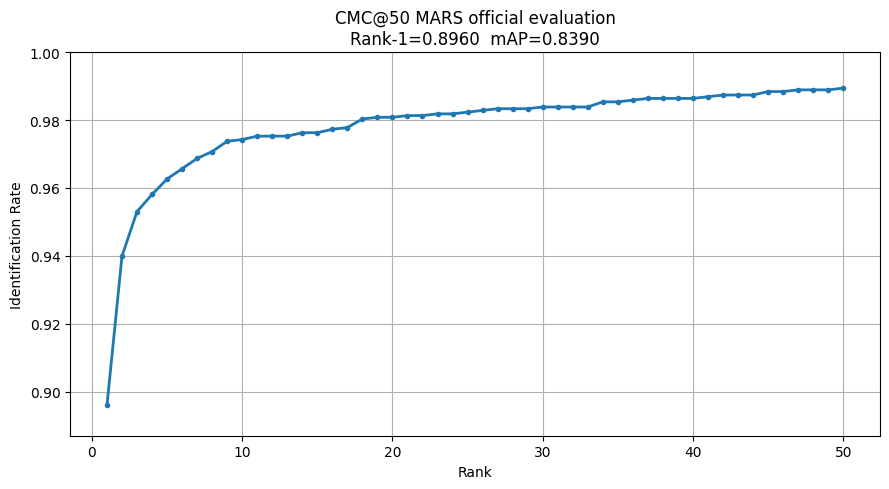

In [ ]:
print('Official MARS evaluation split' + ('with flip TTA' if FLIP_TTA else ''))
print(f'  queries scored : {len(aps)}/{len(query_idx)}')
print(f'  Rank-1   : {cmc_official[0]:.4f}')
print(f'  Rank-5   : {cmc_official[4]:.4f}')
print(f'  Rank-10  : {cmc_official[9]:.4f}')
print(f'  Rank-20  : {cmc_official[19]:.4f}')
print(f'  mAP      : {mAP_official:.4f}')

plt.figure(figsize=(9, 5))
plt.plot(range(1, MAX_RANK + 1), cmc_official, marker='o', linewidth=2, markersize=3)
plt.xlabel('Rank')
plt.ylabel('Identification Rate')
plt.title(f'CMC@50 MARS official evaluation\nRank-1={cmc_official[0]:.4f}  mAP={mAP_official:.4f}')
plt.ylim(cmc_official[0] * 0.99, 1)
plt.grid(True)
plt.tight_layout()
plt.savefig('mars_cmc_official.png', dpi=150)
plt.show()


In [20]:
q_exp     = aqe(query_embs, all_embs, k=7, alpha=3.0)
dist_aqe  = 1.0 - (q_exp @ all_embs.T)

aps, cmcs = [], []
for i in range(len(query_idx)):
    ap, cmc = compute_ap_cmc_mars(dist_aqe[i], query_pids[i], query_cams[i],
                                   gallery_pids, gallery_cams, max_rank=20)
    if ap is not None:
        aps.append(ap); cmcs.append(cmc)
print(f'AQE only:         Rank-1={np.stack(cmcs).mean(0)[0]:.4f}  '
      f'mAP={np.mean(aps):.4f}')

for k1 in [10, 12, 14, 16]:
    for lam in [0.2, 0.25, 0.3, 0.35]:
        dist_rr = re_ranking(query_embs, all_embs, k1=k1, k2=2, lambda_value=lam)
        aps, cmcs = [], []
        for i in range(len(query_idx)):
            ap, cmc = compute_ap_cmc_mars(dist_rr[i], query_pids[i], query_cams[i],
                                           gallery_pids, gallery_cams, max_rank=20)
            if ap is not None:
                aps.append(ap); cmcs.append(cmc)
        r1 = np.stack(cmcs).mean(0)[0]
        m  = np.mean(aps)
        print(f'k1={k1:2d} λ={lam:.2f}  Rank-1={r1:.4f}  mAP={m:.4f}')


AQE only:         Rank-1=0.9126  mAP=0.8572
k1=10 λ=0.20  Rank-1=0.8652  mAP=0.8408
k1=10 λ=0.25  Rank-1=0.8717  mAP=0.8428
k1=10 λ=0.30  Rank-1=0.8753  mAP=0.8437
k1=10 λ=0.35  Rank-1=0.8788  mAP=0.8459
k1=12 λ=0.20  Rank-1=0.8722  mAP=0.8458
k1=12 λ=0.25  Rank-1=0.8773  mAP=0.8478
k1=12 λ=0.30  Rank-1=0.8783  mAP=0.8485
k1=12 λ=0.35  Rank-1=0.8788  mAP=0.8487
k1=14 λ=0.20  Rank-1=0.8667  mAP=0.8449
k1=14 λ=0.25  Rank-1=0.8687  mAP=0.8463
k1=14 λ=0.30  Rank-1=0.8717  mAP=0.8476
k1=14 λ=0.35  Rank-1=0.8732  mAP=0.8485
k1=16 λ=0.20  Rank-1=0.8626  mAP=0.8457
k1=16 λ=0.25  Rank-1=0.8682  mAP=0.8469
k1=16 λ=0.30  Rank-1=0.8702  mAP=0.8486
k1=16 λ=0.35  Rank-1=0.8737  mAP=0.8496
